<a href="https://colab.research.google.com/github/MelissaWachira/Accuracy-report/blob/main/AITermProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Health Chatbot
Task:To develop a simple AI chatbot to assist Kenyatta National Hospital in answering frequently asked
customer questions

#Introduction
PAMOJABOT is an intelligent, AI-powered chatbot designed to provide accessible, reliable, and user-friendly information about KNH. Pamojabot aims to offer instant, accurate responses that support users in answering patient questionsmore effectively. The chatbot leverages natural language processing to interact conversationally, making it easier for users to seek guidance anytime, anywhere.

#Problem Statement
To develop a 24/7 automated assistant that reduces the workload on KNH's customer service desk by answering frequently asked questions (FAQs) about clinic schedules, billing, patient location, and visiting hours.

**Objectives**
1. Primary Objectives

The main goal is to transition from a manual information desk to an automated digital system.

24/7 Availability: To provide an automated assistant that is accessible to patients and their families at any time of day or night, regardless of hospital staff working hours.

Workload Reduction: To decrease the physical and cognitive burden on KNH’s customer service desk by automating responses to repetitive queries.

Information Accuracy: To ensure that patients receive consistent and verified information regarding hospital protocols.

2. Technical Objectives

These focus on the development and performance of the PAMOJABOT system.

Natural Language Understanding: To leverage Natural Language Processing to allow the chatbot to interact with users in a conversational and user-friendly manner.

High Intent Recognition: To achieve high accuracy in identifying user needs across specific domains like clinic schedules, billing, and visiting hours.

Efficient Retrieval: To implement a TF-IDF vectorization and cosine similarity model that provides near-instantaneous responses to user inquiries.

Functional Interface: To deploy a web-based demo using Gradio that allows for real-time testing and parameter adjustment (such as similarity thresholds).

3. Social and Operational Objectives

These objectives address the impact of the tool on the KNH community.

Enhanced Patient Experience: To reduce wait times and congestion at the hospital's physical information desks, making the seeking of guidance easier for users anywhere.

Inclusivity: To eventually develop a system that understands local linguistic nuances, such as code-switching between English and Swahili, to serve a diverse population.

Staff Augmentation: To allow human customer service agents to shift their focus from routine FAQs to more complex cases that require high levels of empathy and critical thinking.

Trust and Transparency: To maintain the reputation of KNH by providing a transparent AI tool that clearly identifies itself to users while protecting patient data privacy.

In [ ]:
#Import Libraries
!pip install -q scikit-learn pandas numpy gradio openpyxl
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import gradio as gr
nltk.download('punkt', quiet=True)

True

In [ ]:
#Load dataset
import ast # Import the ast module to safely evaluate string literals

file="/content/knh_faq_data.csv"
df = pd.read_csv(file, index_col='intent_id')

# Convert the string representation of lists in 'question_keywords' to actual lists
df['question_keywords'] = df['question_keywords'].apply(ast.literal_eval)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   question_keywords  20 non-null     object
 1   response           20 non-null     object
dtypes: object(2)
memory usage: 480.0+ bytes


In [ ]:
#Cleaning The Data
#libary that contains punctuation
import string
string.punctuation

#defining the function to remove punctuation
def remove_punctuation(text):
  punctuationfree="".join([i for i in text if i not in string.punctuation])
  return punctuationfree
  #storing the puntuation free text
df['response']=df['response'].apply(lambda x:remove_punctuation(x))
df.head()

,question_keywords,response
intent_id,,
1,"[maternity, delivery, baby, pregnancy, childbi...",Our maternity ward is open 247 For normal deli...
2,"[outpatient, clinic, doctor, see doctor, consu...",The Outpatient Department OPD is open Monday t...
3,"[visiting hours, visit patient, see patient, v...",General visiting hours are from 400 PM to 600 ...
4,"[nhif, insurance, cover, card, medical cover, ...",KNH accepts NHIF AAR Jubilee CIC UAP and other...
5,"[location, direction, where, address, gate, en...",Kenyatta National Hospital is located along Ho...


In [ ]:
#Lowering the Text
df['msg_lower'] = df['response'].str.lower()
df

,question_keywords,response,msg_lower
intent_id,,,
1,"[maternity, delivery, baby, pregnancy, childbi...",Our maternity ward is open 247 For normal deli...,our maternity ward is open 247 for normal deli...
2,"[outpatient, clinic, doctor, see doctor, consu...",The Outpatient Department OPD is open Monday t...,the outpatient department opd is open monday t...
3,"[visiting hours, visit patient, see patient, v...",General visiting hours are from 400 PM to 600 ...,general visiting hours are from 400 pm to 600 ...
4,"[nhif, insurance, cover, card, medical cover, ...",KNH accepts NHIF AAR Jubilee CIC UAP and other...,knh accepts nhif aar jubilee cic uap and other...
5,"[location, direction, where, address, gate, en...",Kenyatta National Hospital is located along Ho...,kenyatta national hospital is located along ho...
6,"[pharmacy, medicine, drugs, prescription, medi...",The main pharmacy is located on the ground flo...,the main pharmacy is located on the ground flo...
7,"[feedback, complaint, issue, speak to manager,...",We value your feedback You can 1 Fill out a cu...,we value your feedback you can 1 fill out a cu...
8,"[cost, price, fee, how much, charges, payment,...",Costs vary depending on the service Approximat...,costs vary depending on the service approximat...
9,"[covid, vaccine, corona, vaccination, covid-19...",The COVID19 vaccination center is located at t...,the covid19 vaccination center is located at t...


In [ ]:
# Create a single string from the list of keywords for the model to 'read'
df['training_text'] = df['question_keywords'].apply(lambda x: " ".join(x))

# Now initialize and train the model using the new string column
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['training_text'])

print("Training successful: Keywords joined and vectorized.")

Training successful: Keywords joined and vectorized.


Tokenization

In [ ]:
#defining function for tokenization
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab', quiet=True)
def tokenization(text):
  tokens=word_tokenize(text)
  return tokens
#applying fn to the columns
df['msg_tokenied']=df['msg_lower'].apply(lambda x: tokenization(x))

Stop Word Removal

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
stopwords=nltk.corpus.stopwords.words('english')

#defining the fn to remove stopwords from tokenized text
def remove_stopwords(tokens):
  output=[i for i in tokens if i not in stopwords]
  return output
#applying the function
df['no_stopwords']=df['msg_tokenied'].apply(lambda x:remove_stopwords(x))

Stemming

In [ ]:
from nltk.stem.porter import PorterStemmer
#defining the object for stemming
porter_stemmer=PorterStemmer()

#defining a fn for stemming
def stemming(text):
  stem_text=[porter_stemmer.stem(word) for word in text]
  return stem_text
  #applying the function
df['msg_stemmed']=df['no_stopwords'].apply(lambda x:stemming(x))

Lemmatization

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
#defining the object for Lemmatization
wordnet_lemmatizer=WordNetLemmatizer()

#defining the fn for lemmatization
def lemmatizer(text):
  lemm_text=[wordnet_lemmatizer.lemmatize(word) for word in text]
  return lemm_text
#applying the function
df['msg_lemmatized']=df['no_stopwords'].apply(lambda x:lemmatizer(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...


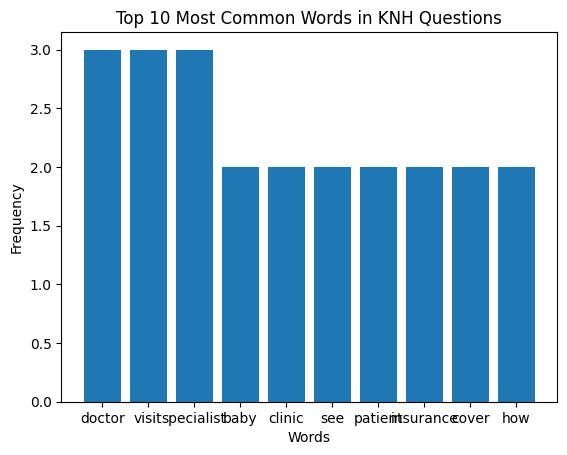

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import re

# Combine all questions into one text
text = " ".join(df["question_keywords"].astype(str)).lower()

# Extract only words
words = re.findall(r'\b[a-z]+\b', text)

# Count word frequencies
common_words = Counter(words).most_common(10)

# Separate words and frequencies
words_list, counts = zip(*common_words)

# Plot bar chart
plt.figure()
plt.bar(words_list, counts)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Common Words in KNH Questions")
plt.show()

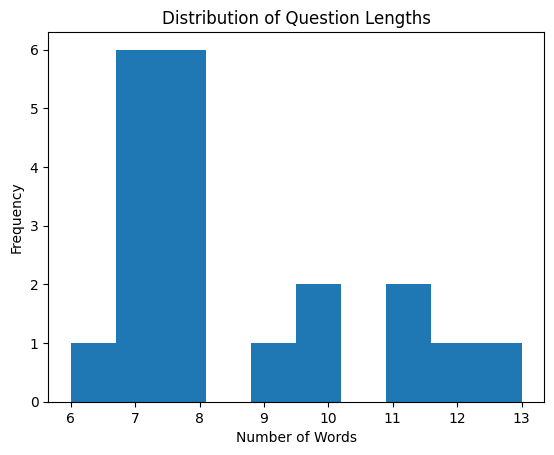

In [ ]:
import matplotlib.pyplot as plt

# Calculate word count per question
question_lengths = df["question_keywords"].astype(str).apply(lambda x: len(x.split()))

# Plot histogram
plt.figure()
plt.hist(question_lengths)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Question Lengths")
plt.show()

In [ ]:
df['clean_text'] = df['msg_lemmatized'].apply(lambda x: ' '.join(x))

print("First 5 entries of df['msg_lemmatized']:")
print(df['msg_lemmatized'].head())
print("\nFirst 5 entries of df['clean_text']:")
print(df['clean_text'].head())

empty_clean_text_count = (df['clean_text'].apply(lambda x: not x.strip())).sum()
print(f"\nNumber of empty or whitespace-only strings in df['clean_text']: {empty_clean_text_count}")
print(f"Total number of documents: {len(df['clean_text'])}")

if empty_clean_text_count == len(df['clean_text']):
    raise ValueError("All documents in 'clean_text' are empty or contain only whitespace after preprocessing. TF-IDF cannot build a vocabulary.")

# Filter out empty strings and store the actual indices (intent_id) of the DataFrame rows
documents_for_tfidf_series = df['clean_text'][df['clean_text'].apply(lambda x: bool(x.strip()))]
original_df_indices = documents_for_tfidf_series.index.tolist() # Store the actual intent_ids

if len(documents_for_tfidf_series) == 0:
    raise ValueError("No non-empty documents available for TF-IDF vectorization after filtering.")

tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1,2))
Q_tfidf = tfidf.fit_transform(documents_for_tfidf_series) # Fit on the Series, preserving its index context
# normalize matrix rows for stable cosine
# (cosine_similarity handles this, but keeping as is is fine)
print("TF-IDF index built. Features:", len(tfidf.get_feature_names_out()))

First 5 entries of df['msg_lemmatized']:
intent_id
1    [maternity, ward, open, 247, normal, delivery,...
2    [outpatient, department, opd, open, monday, fr...
3    [general, visiting, hour, 400, pm, 600, pm, da...
4    [knh, accepts, nhif, aar, jubilee, cic, uap, m...
5    [kenyatta, national, hospital, located, along,...
Name: msg_lemmatized, dtype: object

First 5 entries of df['clean_text']:
intent_id
1    maternity ward open 247 normal delivery cost r...
2    outpatient department opd open monday friday 8...
3    general visiting hour 400 pm 600 pm daily inte...
4    knh accepts nhif aar jubilee cic uap major ins...
5    kenyatta national hospital located along hospi...
Name: clean_text, dtype: object

Number of empty or whitespace-only strings in df['clean_text']: 0
Total number of documents: 20
TF-IDF index built. Features: 1202


In [ ]:
#Replacement Cell: Retrieval function (TF-IDF) with top-k support ---
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Define stopwords and stemmer/lemmatizer once globally for efficiency
stopwords_list = nltk.corpus.stopwords.words('english')
porter_stemmer = PorterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

def clean_text_for_query(text):
    # Remove punctuation
    # Removed unnecessary backslashes for '(', ')', '[', ']', '{', '}'
    text = ''.join([char for char in text if char not in '"#$%&()*+,-./:;<=>?@[]^_`{}|~'])
    # Lowercasing
    text = text.lower()
    # Tokenization
    tokens = word_tokenize(text)
    # Stop word removal
    tokens = [word for word in tokens if word not in stopwords_list]
    # Lemmatization (using lemmatization as it was the final step for df['msg_lemmatized'])
    tokens = [wordnet_lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

def get_topk_tfidf(user_query, top_k=3):
    """
    Returns a list of top_k candidate dicts with keys: question, answer, score
    Always returns a list (possibly empty).
    """
    uq = str(user_query).strip()
    if uq == "":
        return []
    # Use the new clean_text_for_query function for the user query
    processed_query = clean_text_for_query(uq)
    if not processed_query.strip(): # Check if query is empty after cleaning
        return []
    v = tfidf.transform([processed_query])
    sims = cosine_similarity(v, Q_tfidf).flatten()
    if np.all(np.isnan(sims)):
        return []

    # Get positional indices of the top-k highest similarity scores
    idx_sorted_positional = sims.argsort()[::-1][:top_k]

    results = []
    # Map these positional indices back to the original DataFrame's intent_id labels
    for i_pos in idx_sorted_positional:
        original_idx = original_df_indices[i_pos] # Get the actual intent_id from the stored list
        results.append({
            "question": df.loc[original_idx]['question_keywords'], # Use .loc for label-based indexing
            "answer": df.loc[original_idx]['response'],          # Use .loc for label-based indexing
            "score": float(sims[i_pos])
        })
    return results

def format_bot_message(top_candidates, show_topk=3):
    """
    Turn top_candidates (list of dicts) into a markdown string for the bot.
    Shows the best answer prominently and then top-k candidates (optional).
    """
    if not top_candidates:
        return "Sorry — I couldn't find a close match. Try rephrasing your question."
    best = top_candidates[0]
    # Primary answer block
    msg = (
        f"**Answer:** {best['answer']}\n\n"
        f"**Matched FAQ:** \"{best['question']}\"\n"
        f"**Similarity:** {best['score']:.2f}\n\n"
    )
    # Add top-k candidates list (excluding the first) to give options
    if len(top_candidates) > 1 and show_topk > 1:
        msg += "**Other close matches:**\n"
        for k, cand in enumerate(top_candidates[1:show_topk], start=2):
            msg += f"{k-1}. \"{cand['question']}\" (score: {cand['score']:.2f})\n"
    return msg

In [ ]:
# Replacement Cell: Quick tests (prints) to confirm retrieval returns answer & matched question ---
tests = [
    "What are the visiting hours?",
    "How often should I check my blood sugar?",
    "what insurance covers are available?"
]

for t in tests:
    candidates = get_topk_tfidf(t, top_k=3)
    print("User:", t)
    if candidates:
        print("Best answer:", candidates[0]['answer'])
        print("Matched FAQ:", candidates[0]['question'])
        print("Score:", f"{candidates[0]['score']:.2f}")
        print("Top3 questions:")
        for c in candidates:
            print(" -", c['question'], f"({c['score']:.2f})")
    else:
        print("No good match found.")
    print()

User: What are the visiting hours?
Best answer: General visiting hours are from 400 PM to 600 PM daily Intensive Care Unit ICU and High Dependency Unit HDU visiting hours are limited to 15 minutes and are strictly between 1100 AM and 1200 PM and 500 PM and 600 PM Only two visitors per patient are allowed at a time Children under 12 years are not permitted in ICU Please bring your identification for security purposes
Matched FAQ: ['visiting hours', 'visit patient', 'see patient', 'visitors', 'visitation', 'family visit', 'ICU visit']
Score: 0.25
Top3 questions:
 - ['visiting hours', 'visit patient', 'see patient', 'visitors', 'visitation', 'family visit', 'ICU visit'] (0.25)
 - ['greeting', 'hello', 'hi', 'jambo', 'niaje', 'habari', 'hey', 'good morning', 'good afternoon'] (0.18)
 - ['admission', 'admitted', 'inpatient', 'ward', 'bed', 'hospitalization', 'stay'] (0.14)

User: How often should I check my blood sugar?
Best answer: The Outpatient Department OPD is open Monday to Friday 800

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
#defining the object for Lemmatization
wordnet_lemmatizer=WordNetLemmatizer()

#defining the fn for lemmatization
def lemmatizer(text):
  lemm_text=[wordnet_lemmatizer.lemmatize(word) for word in text]
  return lemm_text
#applying the function
df['msg_lemmatized']=df['no_stopwords'].apply(lambda x:lemmatizer(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(max_features=2500)
x = cv.fit_transform(documents_for_tfidf_series).toarray()

In [ ]:
x.shape

(20, 428)

In [ ]:
y=pd.get_dummies(df.index)
y

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [ ]:
y=y.iloc[:,1].values

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB().fit(xtrain,ytrain)

In [ ]:
ypred=model.predict(xtest)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(ytest,ypred)*100
accuracy

75.0

In [ ]:
import gradio as gr

def gr_chat(user_message, history, top_k, min_score):
    """
    history: list of {"role": "...", "content": "..."} messages
    """
    history = history or []
    user_message = (user_message or "").strip()

    if user_message == "":
        return history, ""

    # add the user message
    history.append({"role": "user", "content": user_message})

    # retrieval
    candidates = get_topk_tfidf(user_message, top_k=top_k)

    if not candidates or candidates[0]['score'] < min_score:
        bot_reply = "Sorry — I couldn't find a close match. Please rephrase your question."
    else:
        bot_reply = format_bot_message(candidates, show_topk=top_k)

    # add bot reply
    history.append({"role": "assistant", "content": bot_reply})

    return history, ""


with gr.Blocks(
    css="""
        .gradio-container { font-family: 'Inter', sans-serif; }
        .title { font-size: 24px; font-weight: 700; }
        .subtitle { font-size: 14px; color: #555; margin-bottom: 14px; }
    """
) as demo:

    gr.Markdown("<div class='title'>PamojaBot — Minimal TF-IDF FAQ Chatbot</div>")
    gr.Markdown("<div class='subtitle'>Ask any KNH-related question and get the closest FAQ answer.</div>")

    with gr.Row():
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(label="Conversation", type="messages", height=420)
            user_input = gr.Textbox(placeholder="Type your question here...", label="Your Question")
            submit_btn = gr.Button("Get Answer", variant="primary")
            clear_btn = gr.Button("Clear Chat")

        with gr.Column(scale=1):
            gr.Markdown("### Settings")
            topk_slider = gr.Slider(1, 5, value=3, label="Top-k matches", step=1)
            min_score = gr.Slider(0, 1, value=0.18, step=0.01, label="Minimum similarity")

            gr.Markdown("### Dataset Preview")
            gr.Dataframe(df[['question_keywords','response']].head(6), interactive=False)

    submit_btn.click(
        fn=gr_chat,
        inputs=[user_input, chatbot, topk_slider, min_score],
        outputs=[chatbot, user_input]
    )

    user_input.submit(
        fn=gr_chat,
        inputs=[user_input, chatbot, topk_slider, min_score],
        outputs=[chatbot, user_input]
    )

    clear_btn.click(lambda: ([], ""), outputs=[chatbot, user_input])

demo.launch(share=True)

/tmp/ipykernel_465/148088340.py:30: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_465/148088340.py:43: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(label="Conversation", type="messages", height=420)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1aa8a69f35d1994a73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Ethical and Societal Reflections**
1. Inclusivity and Linguistic Justice
Kenya is a linguistically diverse nation where code-switching among English, Swahili, and Sheng is common. An ethical chatbot must not only understand formal language but also the local dialects used by the diverse patient base at KNH. If the AI only works for English speakers, it creates a digital divide, unfairly disadvantaging patients from rural or less educated backgrounds.

2. Privacy and Data Protection (DPA 2019)
The chatbot handles sensitive data like patient locations and billing information. You must align with the Kenya Data Protection Act of 2019. Ethically, the system must ensure that private patient data is not leaked to unauthorized users. For example, the bot should never disclose a patient's room number to a stranger without proper verification protocols.

3. Accuracy and the Risk of Harm
In a hospital setting, a hallucination where the AI makes up a wrong answer—can have serious consequences. If a chatbot gives the wrong clinic hours, a patient might travel long distances at great expense only to find the facility closed. Ethically, the AI must have a confidence threshold; if it is not sure of an answer, it should stay silent and direct the user to a human staff member to prevent misinformation.

4. Human-Centric Automation
There is often a fear that AI will replace human jobs at hospital front desks. The goal of the KNH chatbot should be to augment the workforce, not replace it. By handling repetitive FAQs, the AI allows human staff to focus on complex cases that require empathy and critical thinking, which robots cannot provide.

5. Transparency and Trust
Patients have a right to know they are interacting with a machine rather than a human. To build public trust, the chatbot should clearly identify itself as an AI assistant. This transparency ensures that patients understand the limitations of the tool and helps maintain the reputation of KNH as a trustworthy institution.

**Challenges in training AI with limited local language data**
1. Lack of Large-Scale Digitized Corpora
Most modern AI models require billions of words to understand context and grammar. While English has massive online archives, many local languages have a small digital footprint. This lack of high-volume digitized text—such as news articles, books, or official documents makes it difficult for the model to learn the foundational rules of the language, often leading to poor fluency and limited vocabulary in the chatbot.

2. High Linguistic Variance and Code-Switching
In a Kenyan hospital setting, patients rarely use a single language exclusively. Instead, they often engage in code-switching, mixing English, Swahili, and Sheng in a single sentence. Standard AI models are typically trained on pure language samples. When faced with a hybrid sentence, the AI can become confused because it lacks enough training examples to map the relationship between these mixed structures.

3. Morphological and Structural Complexity
Many local languages are agglutinative, meaning they combine various grammatical elements (subject, tense, and action) into a single, complex word. While humans process these nuances naturally, an AI trained on limited data struggles to deconstruct these words. This can lead to the chatbot misinterpreting the time of an appointment or the subject of a query, which is a critical error in a healthcare environment.

4. Scarcity of Annotated Medical Datasets
For a KNH assistant to be effective, it needs more than just basic language skills; it needs to understand medical and administrative intent. Creating datasets where local phrases are correctly labeled (e.g., identifying a specific clinic or a billing concern) requires human experts. Because this process is expensive and time-consuming, there is a major shortage of the high-quality, labeled data required to fine-tune an AI for specific hospital functions.

5. Increased Risk of Algorithmic Bias and Hallucinations
When an AI model is trained on thin or unrepresentative data, it often attempts to fill in the gaps using patterns from more dominant languages like English. This results in hallucinations where the AI provides a confident but factually incorrect answer. In a high-stakes environment like a national hospital, providing an incorrect clinic schedule or wrong visiting hours due to a linguistic misunderstanding can cause significant operational disruptions

**Future Improvements**

1. Multilingual Support and Dialect Adaptation
The current model is primarily trained on English keywords, which may exclude a significant portion of the patient population.

Improvement: Integrate Swahili and Sheng NLP libraries to allow the bot to understand and respond in the languages most commonly used for code-switching in Kenya.

Implementation: Use cross-lingual embeddings like LASER or mBART so the bot can understand a Swahili query even if the answer is stored in English.

2. Integration with Real-Time Hospital Systems
Currently, the bot relies on a static CSV file, meaning it cannot provide live updates.

Improvement: Connect the bot to the Kenyatta National Hospital Health Information Management System via APIs.

Impact: This would enable the bot to provide real-time information, such as the current wait time for specific clinics or the exact admission status of a patient, rather than just general visiting hours.

3. Transition to Large Language Models
Your current system uses TF-IDF and Naive Bayes, which are excellent for simple FAQs but struggle with complex, conversational context.

Improvement: Implement a Retrieval-Augmented Generation architecture using models like GPT-4 or Llama-3.

Benefit: This would allow the bot to handle multi-turn conversations (remembering what the user said in the previous sentence) and provide more human-like and empathetic responses.

4. Voice-to-Text and Accessibility Features
Many patients visiting KNH may have literacy challenges or physical disabilities that make typing difficult.

Improvement: Add a voice interface using Speech-to-Text and Text-to-Speech technologies.

Impact: This would allow users to simply speak their questions to the bot, making the technology significantly more inclusive and accessible to the elderly and the visually impaired.

5. Automated Feedback and Self-Learning Loops
The feedback mechanism is currently manual or based on simple similarity scores.

Improvement: Develop a Reinforcement Learning from Human Feedback pipeline.

Benefit: The system could automatically flag queries where users gave a "thumbs down" and prioritize those specific interactions for the next training cycle, allowing PAMOJABOT to get smarter autonomously over time.